**Tes Suhu**

In [ ]:
cargo_profiles = {
    'vaksin_2_8C': {'min': 2.0, 'max': 8.0, 'massa_kg': 300, 'toleransi_menit': 30},
    'daging_beku': {'min': -25.0, 'max': -18.0, 'massa_kg': 2000, 'toleransi_menit': 120},
    'ikan_segar': {'min': 0.0, 'max': 5.0, 'massa_kg': 1200, 'toleransi_menit': 45},
    'sayur_buah': {'min': 2.0, 'max': 4.0, 'massa_kg': 1500, 'toleransi_menit': 90},
    'produk_susu': {'min': 2.0, 'max': 4.0, 'massa_kg': 900, 'toleransi_menit': 60},
}

cargo_profiles

{'vaksin_2_8C': {'min': 2.0,
  'max': 8.0,
  'massa_kg': 300,
  'toleransi_menit': 30},
 'daging_beku': {'min': -25.0,
  'max': -18.0,
  'massa_kg': 2000,
  'toleransi_menit': 120},
 'ikan_segar': {'min': 0.0,
  'max': 5.0,
  'massa_kg': 1200,
  'toleransi_menit': 45},
 'sayur_buah': {'min': 2.0,
  'max': 4.0,
  'massa_kg': 1500,
  'toleransi_menit': 90},
 'produk_susu': {'min': 2.0,
  'max': 4.0,
  'massa_kg': 900,
  'toleransi_menit': 60}}

In [ ]:
k_cool = 50   # dinaikkan drastis dari 0.15
k_leak = 0.5  # disesuaikan proporsinya juga
k_door = 8.0
k_solar = 0.05

# ulangi loop simulasi dengan noise lebih kecil
T = np.zeros(n_steps)
T[0] = T_setpoint
np.random.seed(42)

for t in range(n_steps - 1):
    dT = (
        - k_cool * u[t] * (T[t] - T_setpoint)
        + k_leak * (T_amb - T[t])
        + k_door * door_open[t] * (T_amb - T[t])
        + k_solar * solar[t] * (1 - shade[t])
    ) / C_thermal

    noise = np.random.normal(0, 0.05)  # dikecilin dari 0.15
    T[t+1] = T[t] + dt * dT + noise

print(f"Suhu min: {T.min():.2f}°C, max: {T.max():.2f}°C, riak: {T.max()-T.min():.2f}°C")

Suhu min: 4.88°C, max: 5.59°C, riak: 0.71°C


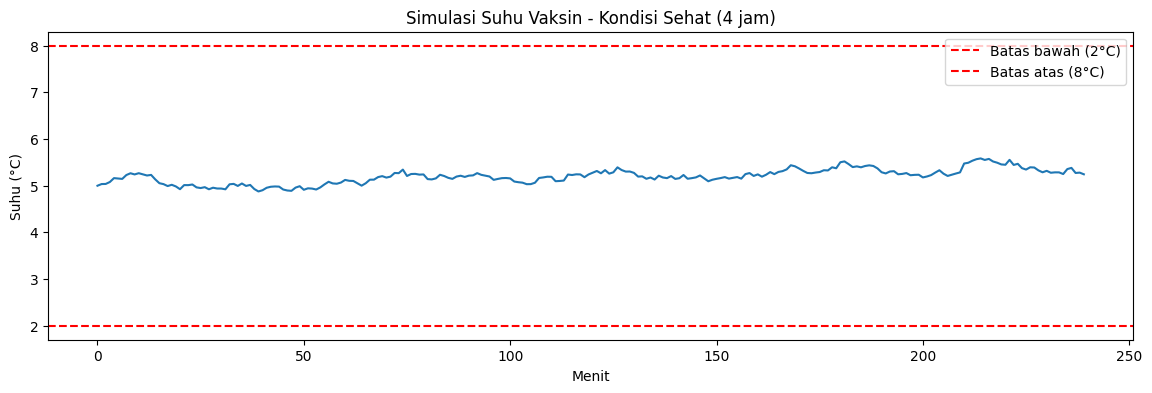

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(T)
plt.axhline(y=cargo_profiles['vaksin_2_8C']['min'], color='r', linestyle='--', label='Batas bawah (2°C)')
plt.axhline(y=cargo_profiles['vaksin_2_8C']['max'], color='r', linestyle='--', label='Batas atas (8°C)')
plt.title('Simulasi Suhu Vaksin - Kondisi Sehat (4 jam)')
plt.xlabel('Menit')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.show()

**Fungsi ambient & solar dinamis** **bold text**

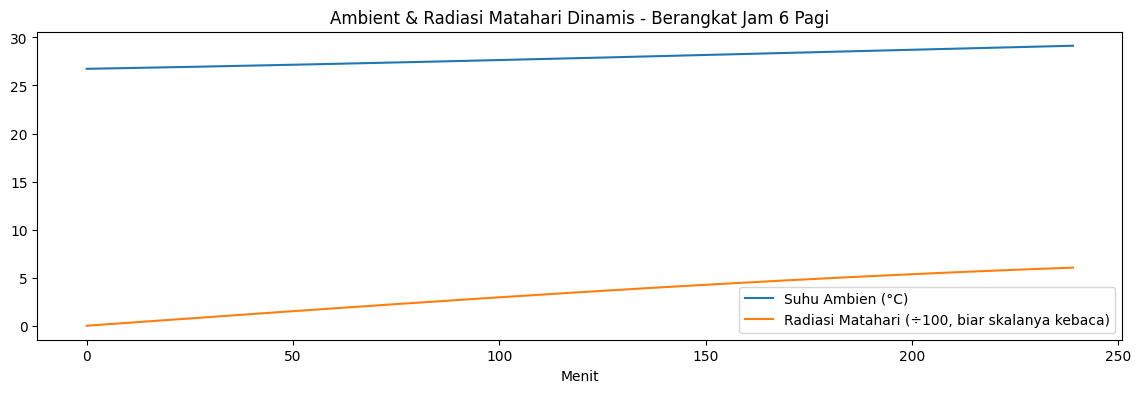

In [ ]:
def generate_ambient_solar(n_steps, start_hour=6):
    """
    Generate suhu ambien & radiasi matahari yang berubah tiap menit,
    berdasarkan pola siklus harian Jakarta yang kita lihat di data NASA POWER.
    """
    hours = (start_hour + np.arange(n_steps) / 60) % 24

    # Suhu ambien: pola sinusoidal, rendah dini hari (~26°C), puncak siang (~31°C)
    T_amb_dynamic = 28.5 + 2.5 * np.sin((hours - 9) * np.pi / 12)

    # Radiasi matahari: 0 di malam hari, puncak siang, pakai fungsi yang dipotong di 0
    solar_dynamic = np.maximum(0, 700 * np.sin((hours - 6) * np.pi / 12))
    solar_dynamic[(hours < 6) | (hours > 18)] = 0  # matahari terbenam malam hari

    return T_amb_dynamic, solar_dynamic

# Coba generate untuk trip yang berangkat jam 6 pagi, durasi 4 jam
T_amb_dyn, solar_dyn = generate_ambient_solar(n_steps, start_hour=6)

plt.figure(figsize=(14,4))
plt.plot(T_amb_dyn, label='Suhu Ambien (°C)')
plt.plot(solar_dyn / 100, label='Radiasi Matahari (÷100, biar skalanya kebaca)')
plt.title('Ambient & Radiasi Matahari Dinamis - Berangkat Jam 6 Pagi')
plt.xlabel('Menit')
plt.legend()
plt.show()

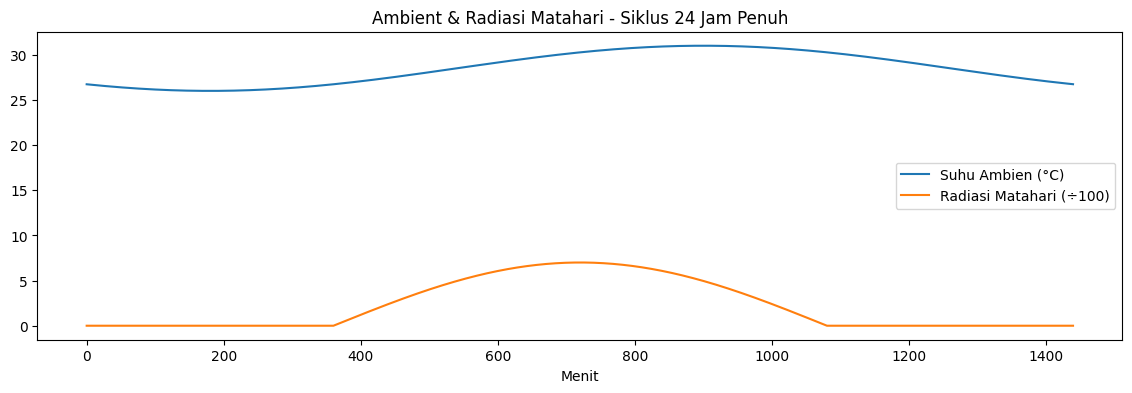

In [ ]:
T_amb_full, solar_full = generate_ambient_solar(1440, start_hour=0)  # 1440 menit = 24 jam

plt.figure(figsize=(14,4))
plt.plot(T_amb_full, label='Suhu Ambien (°C)')
plt.plot(solar_full / 100, label='Radiasi Matahari (÷100)')
plt.title('Ambient & Radiasi Matahari - Siklus 24 Jam Penuh')
plt.xlabel('Menit')
plt.legend()
plt.show()

**Gabungkan ambient dinamis ke simulasi suhu**

In [ ]:
T_amb_dyn, solar_dyn = generate_ambient_solar(n_steps, start_hour=6)  # trip 4 jam, berangkat jam 6 pagi

shade = np.zeros(n_steps)  # asumsi truk box tertutup, belum ada efek shading

T = np.zeros(n_steps)
T[0] = T_setpoint
np.random.seed(42)

for t in range(n_steps - 1):
    dT = (
        - k_cool * u[t] * (T[t] - T_setpoint)
        + k_leak * (T_amb_dyn[t] - T[t])
        + k_door * door_open[t] * (T_amb_dyn[t] - T[t])
        + k_solar * solar_dyn[t] * (1 - shade[t])
    ) / C_thermal

    noise = np.random.normal(0, 0.05)
    T[t+1] = T[t] + dt * dT + noise

print(f"Suhu min: {T.min():.2f}°C, max: {T.max():.2f}°C, riak: {T.max()-T.min():.2f}°C")

Suhu min: 4.93°C, max: 6.11°C, riak: 1.17°C


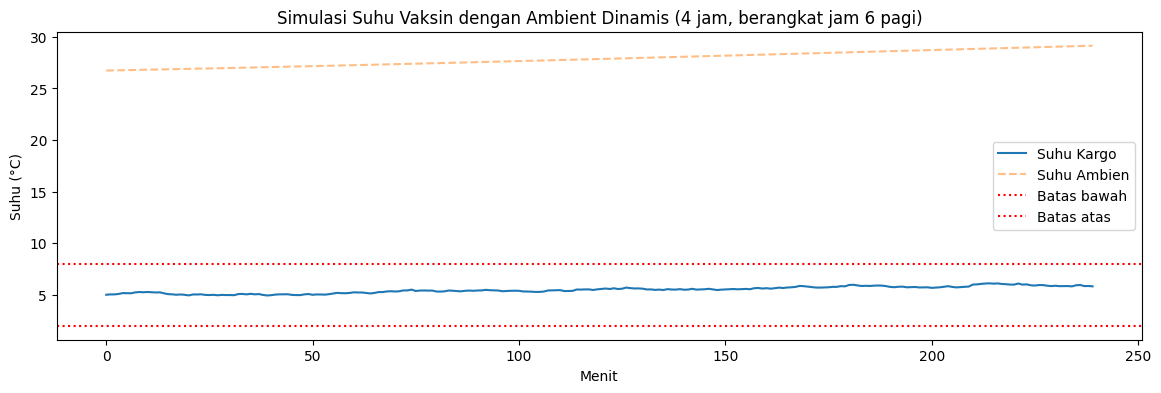

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(T, label='Suhu Kargo')
plt.plot(T_amb_dyn, label='Suhu Ambien', alpha=0.5, linestyle='--')
plt.axhline(y=cargo_profiles['vaksin_2_8C']['min'], color='r', linestyle=':', label='Batas bawah')
plt.axhline(y=cargo_profiles['vaksin_2_8C']['max'], color='r', linestyle=':', label='Batas atas')
plt.title('Simulasi Suhu Vaksin dengan Ambient Dinamis (4 jam, berangkat jam 6 pagi)')
plt.xlabel('Menit')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.show()

**Reefer Mati Total**

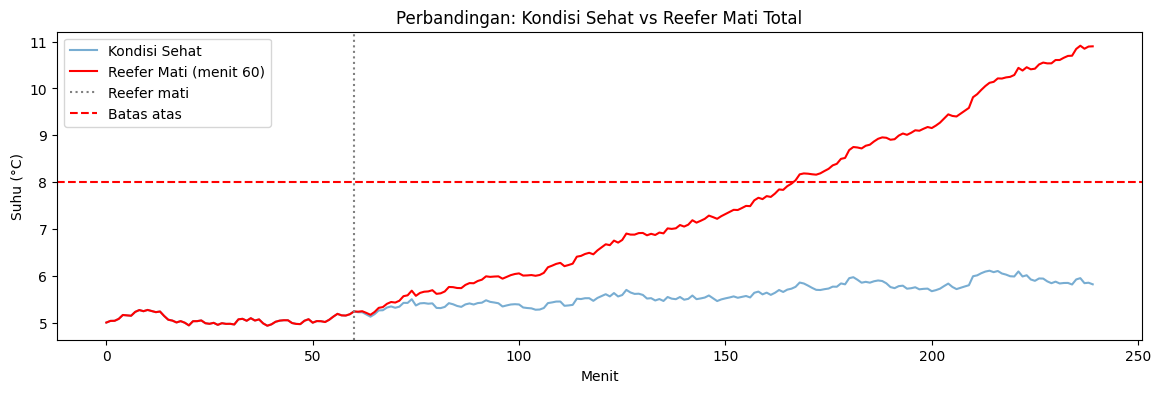

In [ ]:
# Skenario: reefer mati total di menit ke-60
u_anomaly = np.ones(n_steps)
u_anomaly[60:] = 0.0  # dari menit 60 sampai akhir, reefer mati total

T_anomaly = np.zeros(n_steps)
T_anomaly[0] = T_setpoint
np.random.seed(42)

for t in range(n_steps - 1):
    dT = (
        - k_cool * u_anomaly[t] * (T_anomaly[t] - T_setpoint)
        + k_leak * (T_amb_dyn[t] - T_anomaly[t])
        + k_door * door_open[t] * (T_amb_dyn[t] - T_anomaly[t])
        + k_solar * solar_dyn[t] * (1 - shade[t])
    ) / C_thermal

    noise = np.random.normal(0, 0.05)
    T_anomaly[t+1] = T_anomaly[t] + dt * dT + noise

plt.figure(figsize=(14,4))
plt.plot(T, label='Kondisi Sehat', alpha=0.6)
plt.plot(T_anomaly, label='Reefer Mati (menit 60)', color='red')
plt.axvline(x=60, color='gray', linestyle=':', label='Reefer mati')
plt.axhline(y=cargo_profiles['vaksin_2_8C']['max'], color='r', linestyle='--', label='Batas atas')
plt.title('Perbandingan: Kondisi Sehat vs Reefer Mati Total')
plt.xlabel('Menit')
plt.ylabel('Suhu (°C)')
plt.legend()
plt.show()

In [ ]:
breach_idx = np.where(T_anomaly > cargo_profiles['vaksin_2_8C']['max'])[0]

if len(breach_idx) > 0:
    breach_minute = breach_idx[0]
    ttb = breach_minute - 60  # dikurangi menit onset anomali (60)
    print(f"Anomali mulai: menit ke-60")
    print(f"Suhu keluar batas aman: menit ke-{breach_minute}")
    print(f"Time-to-Breach: {ttb} menit")
else:
    print("Suhu tidak pernah keluar batas dalam durasi trip ini")

Anomali mulai: menit ke-60
Suhu keluar batas aman: menit ke-167
Time-to-Breach: 107 menit


**Fungsi simulate_trip**

In [ ]:
def simulate_trip(cargo_type, n_steps=240, start_hour=6,
                   anomaly_type=None, onset_minute=None,
                   k_cool=50, k_leak=0.5, k_door=8.0, k_solar=0.05,
                   seed=None):
    """
    Simulasikan satu perjalanan truk cold chain.

    cargo_type: nama profil muatan (harus ada di cargo_profiles)
    n_steps: durasi trip dalam menit
    start_hour: jam berangkat (0-23)
    anomaly_type: None (sehat) atau kode anomali seperti 'A3'
    onset_minute: menit terjadinya anomali (wajib diisi kalau anomaly_type bukan None)
    seed: buat reproducibility
    """
    profile = cargo_profiles[cargo_type]
    T_setpoint = (profile['min'] + profile['max']) / 2
    C_thermal = profile['massa_kg'] * 3.5

    T_amb, solar = generate_ambient_solar(n_steps, start_hour=start_hour)
    shade = np.zeros(n_steps)

    # Kondisi dasar: sehat
    u = np.ones(n_steps)
    door_open = np.zeros(n_steps)

    # Suntik anomali kalau diminta
    if anomaly_type == 'A3':  # reefer mati total
        u[onset_minute:] = 0.0
    elif anomaly_type == 'A1':  # pintu terbuka lama
        door_open[onset_minute:onset_minute+20] = 1.0
    # (kode anomali lain nanti ditambahin di sini satu-satu)

    T = np.zeros(n_steps)
    T[0] = T_setpoint
    if seed is not None:
        np.random.seed(seed)

    for t in range(n_steps - 1):
        dT = (
            - k_cool * u[t] * (T[t] - T_setpoint)
            + k_leak * (T_amb[t] - T[t])
            + k_door * door_open[t] * (T_amb[t] - T[t])
            + k_solar * solar[t] * (1 - shade[t])
        ) / C_thermal
        noise = np.random.normal(0, 0.05)
        T[t+1] = T[t] + dt * dT + noise

    # Hitung label
    is_anomaly = 1 if anomaly_type is not None else 0
    breach_idx = np.where((T < profile['min']) | (T > profile['max']))[0]
    if len(breach_idx) > 0 and onset_minute is not None:
        relevant_breach = breach_idx[breach_idx >= onset_minute]
        time_to_breach = relevant_breach[0] - onset_minute if len(relevant_breach) > 0 else 999
    else:
        time_to_breach = 999

    return {
        'temp_profile': T,
        'ambient_profile': T_amb,
        'solar_profile': solar,
        'is_anomaly': is_anomaly,
        'failure_mode': anomaly_type if anomaly_type else 'A0',
        'time_to_breach': time_to_breach,
        'cargo_type': cargo_type
    }

Kondisi Sehat - TTB: 999, Label: A0
Reefer Mati - TTB: 107, Label: A3


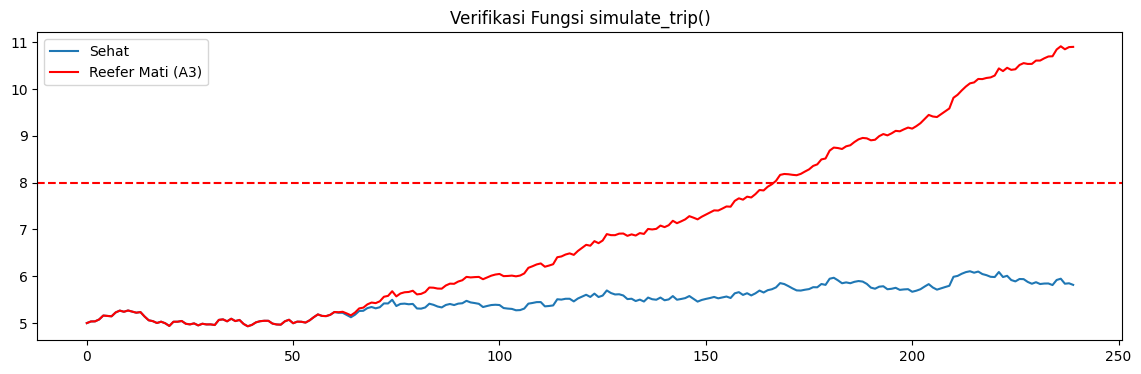

In [ ]:
result_sehat = simulate_trip('vaksin_2_8C', anomaly_type=None, seed=42)
result_anomali = simulate_trip('vaksin_2_8C', anomaly_type='A3', onset_minute=60, seed=42)

print(f"Kondisi Sehat - TTB: {result_sehat['time_to_breach']}, Label: {result_sehat['failure_mode']}")
print(f"Reefer Mati - TTB: {result_anomali['time_to_breach']}, Label: {result_anomali['failure_mode']}")

plt.figure(figsize=(14,4))
plt.plot(result_sehat['temp_profile'], label='Sehat')
plt.plot(result_anomali['temp_profile'], label='Reefer Mati (A3)', color='red')
plt.axhline(y=cargo_profiles['vaksin_2_8C']['max'], color='r', linestyle='--')
plt.legend()
plt.title('Verifikasi Fungsi simulate_trip()')
plt.show()

**Update fungsi dengan semua anomali**

In [ ]:
def simulate_trip(cargo_type, n_steps=240, start_hour=6,
                   anomaly_type=None, onset_minute=None,
                   k_cool=50, k_leak=0.5, k_door=8.0, k_solar=0.05,
                   seed=None):

    profile = cargo_profiles[cargo_type]
    T_setpoint = (profile['min'] + profile['max']) / 2
    C_thermal = profile['massa_kg'] * 3.5

    T_amb, solar = generate_ambient_solar(n_steps, start_hour=start_hour)
    shade = np.zeros(n_steps)
    solar_multiplier = np.ones(n_steps)  # BARU: pengali efek matahari

    u = np.ones(n_steps)
    door_open = np.zeros(n_steps)
    k_cool_t = np.full(n_steps, k_cool)
    T_init = T_setpoint

    if anomaly_type == 'A1':
        door_open[onset_minute:onset_minute+20] = 1.0

    elif anomaly_type == 'A2':
        durasi = 180
        akhir = min(onset_minute + durasi, n_steps)
        u[onset_minute:akhir] = np.linspace(1.0, 0.3, akhir - onset_minute)
        u[akhir:] = 0.3

    elif anomaly_type == 'A3':
        u[onset_minute:] = 0.0

    elif anomaly_type == 'A4':
        k_cool_t[onset_minute:] = k_cool * 0.6

    elif anomaly_type == 'A7':  # FIX: sekarang beneran ngaruh
        akhir = min(onset_minute + 30, n_steps)
        solar_multiplier[onset_minute:akhir] = 3.0  # macet = kurang aliran udara pendingin

    elif anomaly_type == 'A8':
        T_init = profile['max'] + 2.0

    T = np.zeros(n_steps)
    T[0] = T_init
    if seed is not None:
        np.random.seed(seed)

    for t in range(n_steps - 1):
        dT = (
            - k_cool_t[t] * u[t] * (T[t] - T_setpoint)
            + k_leak * (T_amb[t] - T[t])
            + k_door * door_open[t] * (T_amb[t] - T[t])
            + k_solar * solar[t] * solar_multiplier[t] * (1 - shade[t])
        ) / C_thermal
        noise = np.random.normal(0, 0.05)
        T[t+1] = T[t] + dt * dT + noise

    T_sensor = T.copy()
    if anomaly_type == 'A5':
        frozen_value = T[onset_minute]
        T_sensor[onset_minute:] = frozen_value
    elif anomaly_type == 'A6':
        n_spikes = 5
        spike_positions = np.random.choice(range(onset_minute, n_steps), n_spikes, replace=False)
        T_sensor[spike_positions] += np.random.uniform(-5, 5, n_spikes)
        gap_start = onset_minute + 10
        T_sensor[gap_start:gap_start+8] = np.nan

    is_anomaly = 1 if anomaly_type is not None else 0
    breach_idx = np.where((T < profile['min']) | (T > profile['max']))[0]
    if len(breach_idx) > 0 and onset_minute is not None:
        relevant_breach = breach_idx[breach_idx >= onset_minute]
        time_to_breach = relevant_breach[0] - onset_minute if len(relevant_breach) > 0 else 999
    elif len(breach_idx) > 0 and anomaly_type == 'A8':
        time_to_breach = breach_idx[0]
    else:
        time_to_breach = 999

    return {
        'temp_profile': T, 'temp_sensor': T_sensor, 'ambient_profile': T_amb,
        'is_anomaly': is_anomaly, 'failure_mode': anomaly_type if anomaly_type else 'A0',
        'time_to_breach': time_to_breach, 'cargo_type': cargo_type
    }

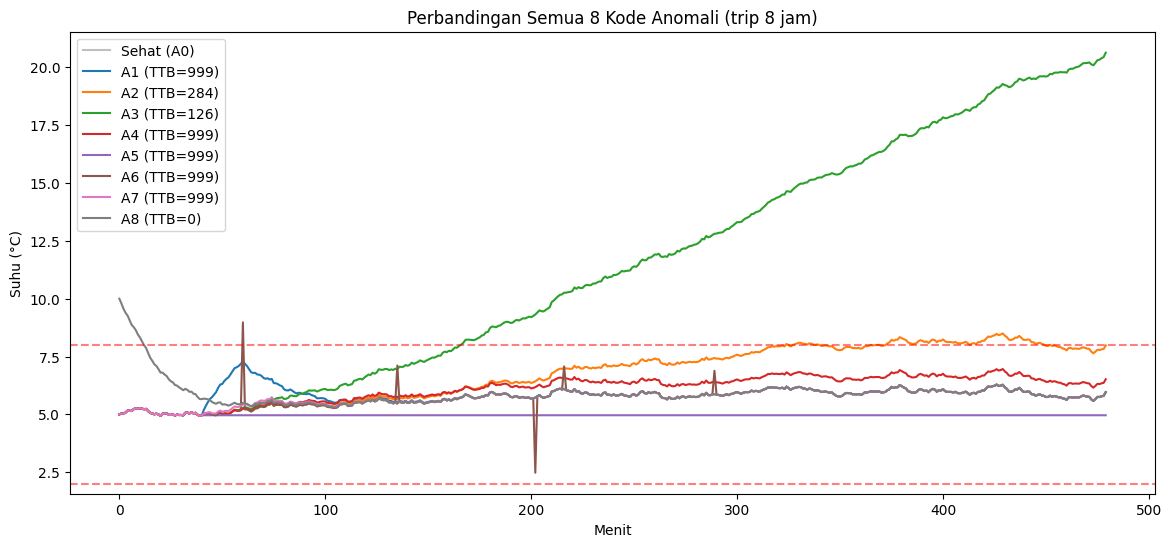

In [ ]:
anomalies_to_test = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']

plt.figure(figsize=(14,6))
sehat = simulate_trip('vaksin_2_8C', n_steps=480, anomaly_type=None, seed=42)
plt.plot(sehat['temp_profile'], label='Sehat (A0)', color='gray', alpha=0.5)

for code in anomalies_to_test:
    onset = 40 if code != 'A8' else None
    result = simulate_trip('vaksin_2_8C', n_steps=480, anomaly_type=code, onset_minute=onset, seed=42)
    plt.plot(result['temp_sensor'], label=f'{code} (TTB={result["time_to_breach"]})')

plt.axhline(y=cargo_profiles['vaksin_2_8C']['max'], color='r', linestyle='--', alpha=0.5)
plt.axhline(y=cargo_profiles['vaksin_2_8C']['min'], color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Perbandingan Semua 8 Kode Anomali (trip 8 jam)')
plt.xlabel('Menit')
plt.ylabel('Suhu (°C)')
plt.show()

In [ ]:
sehat_std = np.std(sehat['temp_profile'][40:])
a4_std = np.std(simulate_trip('vaksin_2_8C', n_steps=480, anomaly_type='A4', onset_minute=40, seed=42)['temp_profile'][40:])
print(f"Variasi suhu - Sehat: {sehat_std:.3f}, A4: {a4_std:.3f}")

Variasi suhu - Sehat: 0.286, A4: 0.482


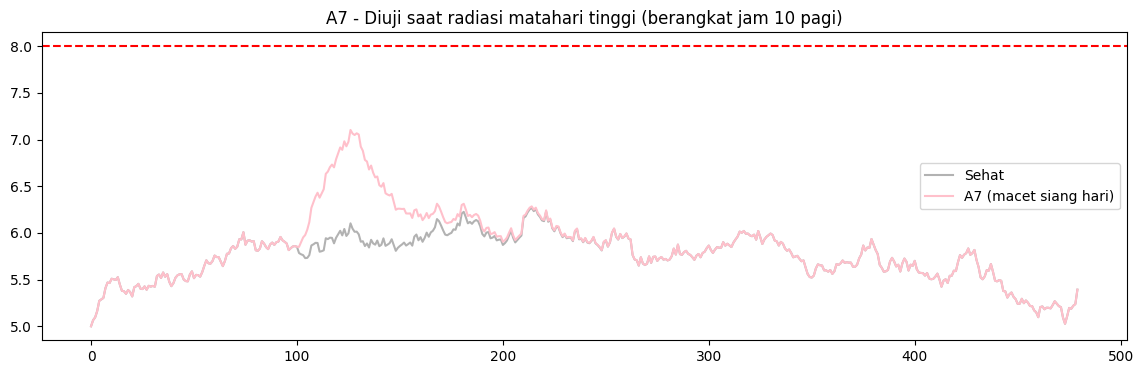

In [ ]:
sehat_siang = simulate_trip('vaksin_2_8C', n_steps=480, start_hour=10, anomaly_type=None, seed=42)
a7_siang = simulate_trip('vaksin_2_8C', n_steps=480, start_hour=10, anomaly_type='A7', onset_minute=100, seed=42)

plt.figure(figsize=(14,4))
plt.plot(sehat_siang['temp_profile'], label='Sehat', color='gray', alpha=0.6)
plt.plot(a7_siang['temp_profile'], label='A7 (macet siang hari)', color='pink')
plt.axhline(y=cargo_profiles['vaksin_2_8C']['max'], color='r', linestyle='--')
plt.legend()
plt.title('A7 - Diuji saat radiasi matahari tinggi (berangkat jam 10 pagi)')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_trip(cargo_type, n_steps=240, start_hour=6,
                   anomaly_type=None, onset_minute=None,
                   k_cool=50, k_leak=0.5, k_door=8.0, k_solar=0.05,
                   seed=None):

    profile = cargo_profiles[cargo_type]
    T_setpoint = (profile['min'] + profile['max']) / 2
    C_thermal = profile['massa_kg'] * 3.5

    T_amb, solar = generate_ambient_solar(n_steps, start_hour=start_hour)
    shade = np.zeros(n_steps)
    solar_multiplier = np.ones(n_steps)

    u = np.ones(n_steps)
    door_open = np.zeros(n_steps)
    k_cool_t = np.full(n_steps, k_cool)
    T_init = T_setpoint

    if anomaly_type == 'A1':
        door_open[onset_minute:onset_minute+20] = 1.0

    elif anomaly_type == 'A2':
        durasi = 120
        akhir = min(onset_minute + durasi, n_steps)
        u[onset_minute:akhir] = np.linspace(1.0, 0.15, akhir - onset_minute)
        u[akhir:] = 0.15

    elif anomaly_type == 'A3':
        u[onset_minute:] = 0.0

    elif anomaly_type == 'A4':
        k_cool_t[onset_minute:] = k_cool * 0.6

    elif anomaly_type == 'A7':
        akhir = min(onset_minute + 30, n_steps)
        solar_multiplier[onset_minute:akhir] = 3.0

    elif anomaly_type == 'A8':
        T_init = profile['max'] + 2.0

    T = np.zeros(n_steps)
    T[0] = T_init
    if seed is not None:
        np.random.seed(seed)

    for t in range(n_steps - 1):
        dT = (
            - k_cool_t[t] * u[t] * (T[t] - T_setpoint)
            + k_leak * (T_amb[t] - T[t])
            + k_door * door_open[t] * (T_amb[t] - T[t])
            + k_solar * solar[t] * solar_multiplier[t] * (1 - shade[t])
        ) / C_thermal
        noise = np.random.normal(0, 0.05)
        T[t+1] = T[t] + dt * dT + noise

    T_sensor = T.copy()
    if anomaly_type == 'A5':
        frozen_value = T[onset_minute]
        T_sensor[onset_minute:] = frozen_value
    elif anomaly_type == 'A6':
        n_spikes = 5
        spike_positions = np.random.choice(range(onset_minute, n_steps), n_spikes, replace=False)
        T_sensor[spike_positions] += np.random.uniform(-5, 5, n_spikes)
        gap_start = onset_minute + 10
        T_sensor[gap_start:gap_start+8] = np.nan

    is_anomaly = 1 if anomaly_type is not None else 0
    breach_idx = np.where((T < profile['min']) | (T > profile['max']))[0]
    if len(breach_idx) > 0 and onset_minute is not None:
        relevant_breach = breach_idx[breach_idx >= onset_minute]
        time_to_breach = relevant_breach[0] - onset_minute if len(relevant_breach) > 0 else 999
    elif len(breach_idx) > 0 and anomaly_type == 'A8':
        time_to_breach = breach_idx[0]
    else:
        time_to_breach = 999

    return {
        'temp_profile': T, 'temp_sensor': T_sensor, 'ambient_profile': T_amb,
        'is_anomaly': is_anomaly, 'failure_mode': anomaly_type if anomaly_type else 'A0',
        'time_to_breach': time_to_breach, 'cargo_type': cargo_type
    }

In [ ]:
df_trips = generate_dataset(n_trips=50)
df_anomaly_only = df_trips[df_trips['is_anomaly'] == 1]

print(f"Total anomali: {len(df_anomaly_only)}")
print(f"Breach rate keseluruhan: {(df_anomaly_only['time_to_breach'] < 999).mean()*100:.1f}%")
print("\nPer jenis anomali:")
print(df_anomaly_only.groupby('failure_mode')['time_to_breach'].apply(lambda x: (x < 999).mean() * 100))

Total anomali: 24
Breach rate keseluruhan: 33.3%

Per jenis anomali:
failure_mode
A1    100.000000
A2     50.000000
A3     50.000000
A4      0.000000
A5      0.000000
A6     16.666667
A7      0.000000
A8    100.000000
Name: time_to_breach, dtype: float64


In [ ]:
df_full = generate_dataset(n_trips=700, seed_base=1000)

print(f"Total trip: {len(df_full)}")
print(f"\nDistribusi sehat vs anomali:")
print(df_full['is_anomaly'].value_counts())

print(f"\nDistribusi jenis muatan:")
print(df_full['cargo_type'].value_counts())

print(f"\nDistribusi failure_mode:")
print(df_full['failure_mode'].value_counts())

df_anomaly = df_full[df_full['is_anomaly'] == 1]
print(f"\nBreach rate keseluruhan: {(df_anomaly['time_to_breach'] < 999).mean()*100:.1f}%")

Total trip: 700

Distribusi sehat vs anomali:
is_anomaly
0    440
1    260
Name: count, dtype: int64

Distribusi jenis muatan:
cargo_type
ikan_segar     158
produk_susu    147
vaksin_2_8C    144
sayur_buah     132
daging_beku    119
Name: count, dtype: int64

Distribusi failure_mode:
failure_mode
A0    440
A6     43
A2     40
A5     37
A1     36
A3     33
A7     28
A4     23
A8     20
Name: count, dtype: int64

Breach rate keseluruhan: 31.5%


In [ ]:
import inspect
print(inspect.getsource(generate_dataset))

def generate_dataset(n_trips=700, seed_base=1000):
    rows = []
    cargo_types = list(cargo_profiles.keys())
    anomaly_codes = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']
    slow_anomalies = ['A2', 'A4']
    
    np.random.seed(seed_base)
    
    for trip_id in range(n_trips):
        cargo = np.random.choice(cargo_types)
        start_hour = np.random.randint(0, 24)
        duration = np.random.randint(240, 480)
        
        is_healthy = np.random.random() < 0.6
        
        if is_healthy:
            anomaly, onset = None, None
        else:
            anomaly = np.random.choice(anomaly_codes)
            if anomaly == 'A8':
                onset = None
            elif anomaly in slow_anomalies:
                onset = np.random.randint(20, max(21, int(duration * 0.3)))
            else:
                onset = np.random.randint(20, duration - 30)
        
        result = simulate_trip(
            cargo_type=cargo, n_steps=duration, start_hour=start_hour,
     

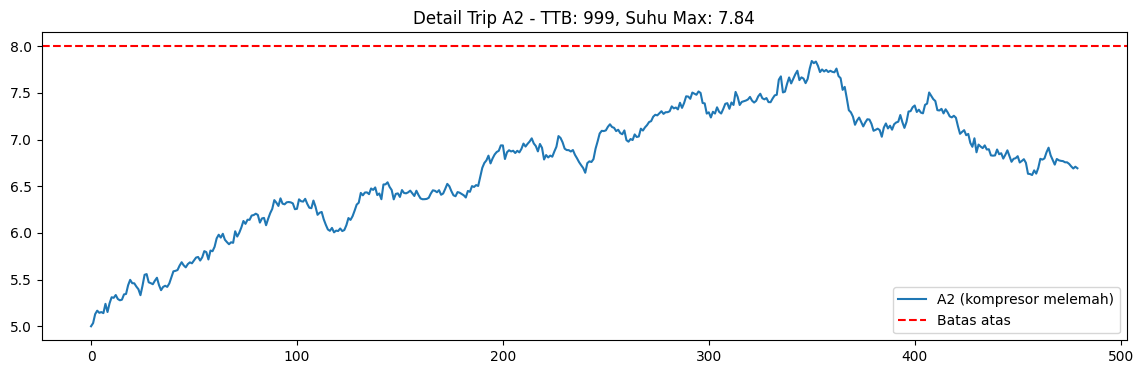

Suhu maksimum tercapai: 7.84°C


In [ ]:
plt.figure(figsize=(14,4))
plt.plot(test_a2['temp_profile'], label='A2 (kompresor melemah)')
plt.axhline(y=8.0, color='r', linestyle='--', label='Batas atas')
plt.title(f'Detail Trip A2 - TTB: {test_a2["time_to_breach"]}, Suhu Max: {test_a2["temp_profile"].max():.2f}')
plt.legend()
plt.show()

print(f"Suhu maksimum tercapai: {test_a2['temp_profile'].max():.2f}°C")

**Fungsi baru: simulate_trip_full (simpan semua kolom per menit)**

In [ ]:
def simulate_trip_full(cargo_type, n_steps=240, start_hour=6,
                        anomaly_type=None, onset_minute=None,
                        k_cool=50, k_leak=0.5, k_door=8.0, k_solar=0.05,
                        seed=None):
    profile = cargo_profiles[cargo_type]
    T_setpoint = (profile['min'] + profile['max']) / 2
    C_thermal = profile['massa_kg'] * 3.5

    T_amb, solar = generate_ambient_solar(n_steps, start_hour=start_hour)
    shade = np.zeros(n_steps)
    solar_multiplier = np.ones(n_steps)
    u = np.ones(n_steps)
    door_open = np.zeros(n_steps)
    k_cool_t = np.full(n_steps, k_cool)
    T_init = T_setpoint
    speed_kmh = np.full(n_steps, 60.0)

    if anomaly_type == 'A1':
        door_open[onset_minute:onset_minute+20] = 1.0
    elif anomaly_type == 'A2':
        durasi = 120
        akhir = min(onset_minute + durasi, n_steps)
        u[onset_minute:akhir] = np.linspace(1.0, 0.15, akhir - onset_minute)
        u[akhir:] = 0.15
    elif anomaly_type == 'A3':
        u[onset_minute:] = 0.0
    elif anomaly_type == 'A4':
        k_cool_t[onset_minute:] = k_cool * 0.6
    elif anomaly_type == 'A7':
        akhir = min(onset_minute + 30, n_steps)
        solar_multiplier[onset_minute:akhir] = 3.0
        speed_kmh[onset_minute:akhir] = 0.0
    elif anomaly_type == 'A8':
        T_init = profile['max'] + 2.0

    if seed is not None:
        np.random.seed(seed)

    T = np.zeros(n_steps)
    T[0] = T_init
    for t in range(n_steps - 1):
        dT = (
            - k_cool_t[t] * u[t] * (T[t] - T_setpoint)
            + k_leak * (T_amb[t] - T[t])
            + k_door * door_open[t] * (T_amb[t] - T[t])
            + k_solar * solar[t] * solar_multiplier[t] * (1 - shade[t])
        ) / C_thermal
        noise = np.random.normal(0, 0.05)
        T[t+1] = T[t] + dt * dT + noise

    T_sensor = T.copy()
    if anomaly_type == 'A5':
        T_sensor[onset_minute:] = T[onset_minute]
    elif anomaly_type == 'A6':
        spike_pos = np.random.choice(range(onset_minute, n_steps), 5, replace=False)
        T_sensor[spike_pos] += np.random.uniform(-5, 5, 5)
        T_sensor[onset_minute+10:onset_minute+18] = np.nan

    is_anomaly = 1 if anomaly_type is not None else 0
    breach_idx = np.where((T < profile['min']) | (T > profile['max']))[0]
    if len(breach_idx) > 0 and onset_minute is not None:
        relevant = breach_idx[breach_idx >= onset_minute]
        time_to_breach = relevant[0] - onset_minute if len(relevant) > 0 else 999
    elif len(breach_idx) > 0 and anomaly_type == 'A8':
        time_to_breach = breach_idx[0]
    else:
        time_to_breach = 999

    # fitur tambahan (kelembapan, jam, durasi reefer, event mengemudi kasar)
    humidity = np.clip(65 + 10*np.sin(np.arange(n_steps)/60*np.pi/12) + np.random.normal(0,1.5,n_steps), 30, 95)
    hour_of_day = ((start_hour + np.arange(n_steps)/60) % 24).astype(int)
    reefer_on = (u > 0).astype(int)

    reefer_duration_min = np.zeros(n_steps)
    counter = 0
    for t in range(n_steps):
        counter = counter + 1 if reefer_on[t] == 1 else 0
        reefer_duration_min[t] = counter

    harsh_events = np.random.poisson(0.05, n_steps)
    delta_temp = np.diff(T_sensor, prepend=T_sensor[0])
    delta_ambient = T_sensor - T_amb

    df_trip = pd.DataFrame({
        'minute': np.arange(n_steps), 'temp_c': T_sensor, 'delta_temp': delta_temp,
        'ambient_c': T_amb, 'delta_ambient': delta_ambient,
        'solar_radiation': solar * solar_multiplier, 'humidity': humidity,
        'door_open': door_open.astype(int), 'reefer_on': reefer_on,
        'reefer_duration_min': reefer_duration_min, 'speed_kmh': speed_kmh,
        'harsh_events': harsh_events, 'hour_of_day': hour_of_day,
    })

    labels = {'is_anomaly': is_anomaly, 'failure_mode': anomaly_type if anomaly_type else 'A0',
              'time_to_breach': time_to_breach, 'cargo_type': cargo_type}
    return df_trip, labels

In [ ]:
  def generate_full_dataset(n_trips=700, seed_base=1000):
    all_dfs = []
    cargo_types = list(cargo_profiles.keys())
    anomaly_codes = ['A1','A2','A3','A4','A5','A6','A7','A8']
    slow_anomalies = ['A2','A4']
    np.random.seed(seed_base)

    for trip_id in range(n_trips):
        cargo = np.random.choice(cargo_types)
        start_hour = np.random.randint(0,24)
        duration = np.random.randint(240,480)
        is_healthy = np.random.random() < 0.6

        if is_healthy:
            anomaly, onset = None, None
        else:
            anomaly = np.random.choice(anomaly_codes)
            if anomaly == 'A8':
                onset = None
            elif anomaly in slow_anomalies:
                onset = np.random.randint(20, max(21,int(duration*0.3)))
            else:
                onset = np.random.randint(20, duration-30)

        df_trip, labels = simulate_trip_full(
            cargo_type=cargo, n_steps=duration, start_hour=start_hour,
            anomaly_type=anomaly, onset_minute=onset, seed=seed_base+trip_id
        )
        df_trip['trip_id'] = trip_id
        df_trip['cargo_type'] = labels['cargo_type']
        df_trip['is_anomaly'] = labels['is_anomaly']
        df_trip['failure_mode'] = labels['failure_mode']
        df_trip['time_to_breach'] = labels['time_to_breach']
        all_dfs.append(df_trip)

    return pd.concat(all_dfs, ignore_index=True)

df_final = generate_full_dataset(n_trips=700)
print(f"Total baris: {len(df_final)}")
print(f"Total kolom: {df_final.shape[1]}")
df_final.head()

Total baris: 250610
Total kolom: 18


,minute,temp_c,delta_temp,ambient_c,delta_ambient,solar_radiation,humidity,door_open,reefer_on,reefer_duration_min,speed_kmh,harsh_events,hour_of_day,trip_id,cargo_type,is_anomaly,failure_mode,time_to_breach
0,0,3.000000,0.000000,27.250000,-24.250000,0.0,65.693909,0,1,1.0,60.0,0,23,0,sayur_buah,1,A7,999
1,1,2.962087,-0.037913,27.240565,-24.278478,0.0,65.396845,0,1,2.0,60.0,0,23,0,sayur_buah,1,A7,999
2,2,2.980807,0.018720,27.231154,-24.250348,0.0,64.103250,0,1,3.0,60.0,0,23,0,sayur_buah,1,A7,999
3,3,2.982025,0.001218,27.221767,-24.239743,0.0,61.854651,0,1,4.0,60.0,0,23,0,sayur_buah,1,A7,999
4,4,3.016721,0.034696,27.212405,-24.195684,0.0,65.173782,0,1,5.0,60.0,0,23,0,sayur_buah,1,A7,999


In [ ]:
!mkdir -p data/processed

In [ ]:
df_final.to_parquet('data/processed/v1_seed1000_700trips.parquet', index=False)
print("Tersimpan!")

Tersimpan!


In [ ]:
!ls -lh data/processed/v1_seed1000_700trips.parquet

-rw-r--r-- 1 root root 9.0M Aug  2 08:47 data/processed/v1_seed1000_700trips.parquet


In [ ]:
print(f"Total baris: {len(df_final):,}")
print(f"Total trip unik: {df_final['trip_id'].nunique()}")
print(f"Kolom: {list(df_final.columns)}")
print(f"\nCek missing value:")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

Total baris: 250,610
Total trip unik: 700
Kolom: ['minute', 'temp_c', 'delta_temp', 'ambient_c', 'delta_ambient', 'solar_radiation', 'humidity', 'door_open', 'reefer_on', 'reefer_duration_min', 'speed_kmh', 'harsh_events', 'hour_of_day', 'trip_id', 'cargo_type', 'is_anomaly', 'failure_mode', 'time_to_breach']

Cek missing value:
temp_c           256
delta_temp       288
delta_ambient    256
dtype: int64


**Split per trip_id, tambah kolom split**

In [15]:
import pandas as pd
df_final = pd.read_parquet('/content/v1_seed1000_700trips.parquet')
print(f"Berhasil dimuat ulang: {len(df_final)} baris")

Berhasil dimuat ulang: 250610 baris


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

unique_trips = df_final['trip_id'].unique()
np.random.seed(2024)  # seed khusus buat split, beda dari seed generate data
np.random.shuffle(unique_trips)

n_total = len(unique_trips)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.15)

train_ids = unique_trips[:n_train]
val_ids = unique_trips[n_train:n_train+n_val]
test_ids = unique_trips[n_train+n_val:]

print(f"Train: {len(train_ids)} trip, Val: {len(val_ids)} trip, Test: {len(test_ids)} trip")

def assign_split(trip_id):
    if trip_id in train_ids:
        return 'train'
    elif trip_id in val_ids:
        return 'val'
    else:
        return 'test'

df_final['split'] = df_final['trip_id'].apply(assign_split)
print(df_final['split'].value_counts())

Train: 489 trip, Val: 105 trip, Test: 106 trip
split
train    174885
test      38564
val       37161
Name: count, dtype: int64


In [18]:
trip_summary = df_final.groupby('trip_id')[['failure_mode', 'split']].first()
print(pd.crosstab(trip_summary['failure_mode'], trip_summary['split']))

split         test  train  val
failure_mode                  
A0              65    290   61
A1               4     27    5
A2               7     22    5
A3               5     32    6
A4               3     17    4
A5               8     30    5
A6               5     20    7
A7               6     27    6
A8               3     24    6


In [20]:
df_final.to_parquet('/content/v1_seed1000_700trips.parquet', index=False)
print("Tersimpan dengan kolom split!")

Tersimpan dengan kolom split!
